In [107]:
from dreimac import GeometryExamples, ComplexProjectiveCoords, ProjectiveMapUtils, PlotUtils
import numpy as np
from persim import plot_diagrams

In [108]:
%load_ext autoreload
%autoreload 2

import utils
import eg_tools
import cechcohomology as cc
import sheaves
import natural_examples as exn
import math_tools_miscellaneous as mtm
import representations as rep

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


bar1 = {'t': [0.2, 0.3, 0.5], 'g': ['g1', 'e', 'g2']}
bar3 = {'t': [0.0, 0.2, 0.8], 'g': ['g0', 'g1', 'g2']}
bar5 = {'t': [0.2, 0.8], 'g': ['g1', 'g2']}
bar2 = {'t': [0.1, 0.5, 0.4], 'g': ['h0', 'h1', 'h2']}
bar4 = {'t': [0.2, 0.4, 0.4], 'g': ['k0', 'k1', 'k2']}
bar6 = {'t': [0.1, 0.1, 0.4, 0.4], 'g': ['h0', 'k0', 'h1·k1', 'h2·k2']}
eg_tools.plot_eg_bars([[bar1, bar2],[bar3, bar4],[bar5,bar6]],marker_size=240,boundary_lw=0.4,fontsize=24,position_title=False,end_labels=False)

# X=S^1, B Z-coordinates

In [133]:
data_S1_FIXED = data_S1

(1000, 2)


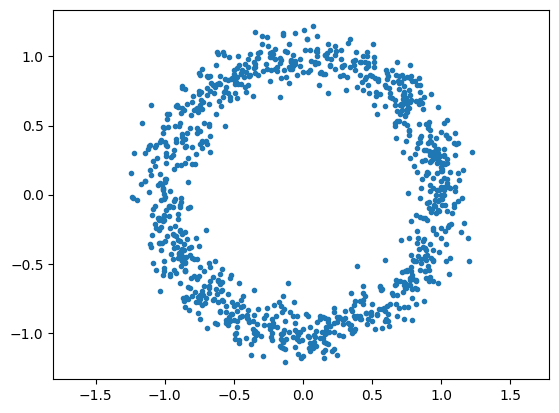

In [147]:
import math
N = 1000
sigma = 0.1
r = 1+np.random.normal(loc=0, scale=sigma, size=N)  # this generates normal distributions
theta = 2*math.pi*np.random.random_sample(size=N) # this generates uniform distributions
x = r*np.cos(theta)
y = r*np.sin(theta)
data_S1 = np.stack((x, y), axis=1)
print(data_S1.shape)
import matplotlib.pyplot as plt
plt.plot(x,y,'.')
plt.axis('equal')
plt.show()

In [148]:
def geodesic_distance(x,y): # x and y both live in R^2
    return np.arccos( (x[0]*y[0] + x[1]*y[1]) / (np.linalg.norm(x) * np.linalg.norm(y)) )

In [149]:
lower_bound = geodesic_distance([1, 0], [1/2, np.sqrt(3)/2]) # 1.0472
upper_bound = geodesic_distance([1, 0], [-1/2, np.sqrt(3)/2]) # 2.094
print(lower_bound, upper_bound)

1.0471975511965976 2.0943951023931957


In [150]:
gamma1 = [upper_bound, 1.6, 1.2]

In [151]:
centers = [[1, 0], [-1/2, np.sqrt(3)/2], [-1/2, -np.sqrt(3)/2]]
exn.nerve(data_S1, centers, geodesic_distance, radius=1.2)

Single sets:
U(0): 381
U(1): 356
U(2): 392

2-fold intersections:
U(0,1): 43
U(0,2): 42
U(1,2): 44

3-fold intersections:
U(0,1,2): 0


In [152]:
open_cover_filtration = exn.compute_open_cover_filtration(data_S1, centers, gamma1, geodesic_distance)

In [153]:
# Base values for each oriented 1-simplex (in standard order)
group = eg_tools.Z

eta_base_values = {
    (0, 1): 1,
    (0, 2): 0,
    (1, 2): 0,
}

In [154]:
EiMacCoords, etas_by_dim = exn.compute_EiMac_coords(eta_base_values, open_cover_filtration, group, data_S1, centers, gamma1, 
                               geodesic_distance, dims_to_keep=(0, 1))

*** Running Eilenberg-MacLane Algorithm ***
Creating eta.
Validating eta:
✓ eta is a Čech 1-cochain over F_Z.
✓ eta is a Čech cocycle.
→ Setting up bump functions g's
· len(g) = 3  (g[0] is None placeholder)

Dimension Lowering:
✓ δ(lifted_eta[i]) == (eta | cover[i])
✓ (lifted_eta[i] | U_i ∩ U_j) - (lifted_eta[j] | U_i ∩ U_j) is a cocycle on U_i ∩ U_j
→ Computing j_sharp(Q(i_sharp(eta))) [from dim 1 to dim 0]
· iter i=1 starting...
· iter i=1 done in 0.9s
· iter i=2 starting...
· iter i=2 done in 0.4s
· Q^1(-) is Done
✓ δ(Q(i_sharp(eta)))  ==  i_sharp(eta)   as Čech cocycles over F_EG.
· New Cech cochain's section is updated as: None
· New eta is a Cech 0-cocycle
→ Gluing eta into a classifying map

Eilenberg-MacLane coordinates is done:
· Domain (index): 0 ~ 999
· Codomain: BG(Z)


In [155]:
# EiMacCoords（BG-valued）
stats_1 = exn.dimension_tuple_stats_on_sheaf_section(EiMacCoords, depth=1)
print(stats_1)
print(f"Non-trivial bars: {sum(stats_1.values())} / {len(EiMacCoords.domain)}")       # 非平凡 bar 总数

Counter({1: 83})
Non-trivial bars: 83 / 1000


In [156]:
eta_0_S1 = rep.cech_cochain_BZ_to_S1(etas_by_dim[0])

In [157]:
EiMacCoords_S1 = cc.zero_cocycle_to_sheaf_section(eta_0_S1)

In [158]:
print(EiMacCoords_S1.grp['name'])
print(EiMacCoords_S1.domain[[0, -1]])

S^1
[  0 999]


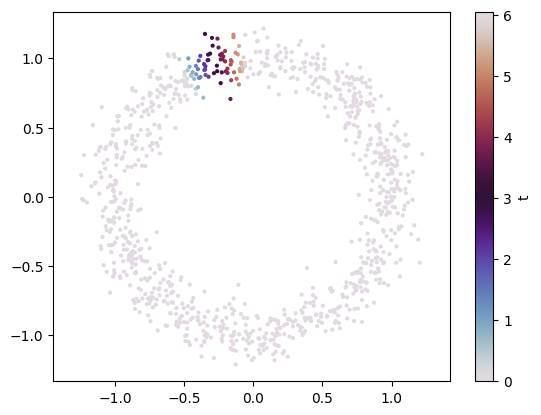

In [159]:
t = [mtm.arg_0_2pi(EiMacCoords_S1(i)) for i in range(0,1000)]
plt.scatter(x, y, c=t, cmap='twilight', s=4)   # s 是点大小，按需调
plt.axis('equal')
plt.colorbar(label='t')   # 可选，显示色条
plt.show()

In [160]:
import numpy as np

# 1. 收集所有点到 complex array
z = np.array([EiMacCoords_S1(i) for i in range(1000)], dtype=complex)   # shape (1000,)

# 2. 一次性算所有 pairwise inner products  ā_i · b_j
inner = np.conj(z)[:, None] * z[None, :]    # shape (1000, 1000), complex

# 3. arccos(Re(·)) with clip
D = np.arccos(np.clip(inner.real, -1.0, 1.0))   # shape (1000, 1000), float in [0, π]

In [161]:
from sklearn.manifold import Isomap

# Isomap
iso = Isomap(
    n_neighbors=10,
    n_components=3,
    metric='precomputed'
)
Y = iso.fit_transform(D)
print(Y.shape)

(1000, 3)


In [162]:
err = iso.reconstruction_error()
print(err)

0.04174133101514487


In [163]:
eigenvalues = np.cumsum(iso.kernel_pca_.eigenvalues_)
print(eigenvalues)
explained = eigenvalues/eigenvalues[-1]
print(explained)

[205.56525936 282.40701358 296.92248964]
[0.6923196  0.95111358 1.        ]


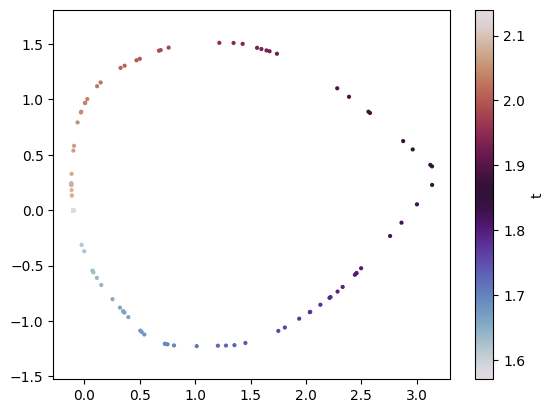

In [170]:
plt.scatter(Y[:,0], Y[:,1], c=theta, cmap='twilight', vmin=1.57, vmax=2.14, s=4)   # s 是点大小，按需调
plt.axis('equal')
plt.colorbar(label='t')   # 可选，显示色条
plt.show()

In [ ]:
plt.scatter(x, y, c=t, cmap='twilight', s=4)   # s 是点大小，按需调
plt.axis('equal')
plt.colorbar(label='t')   # 可选，显示色条
plt.show()

In [166]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=x,
            y=y,
            z=Y[:,0],
            mode='markers',
            marker=dict(
                size=3,
                color=Y[:,1],
                colorscale='Viridis',
                opacity=0.8,
                colorbar=dict(
                    title="data[:,0]"
                )
            )
        )
    ]
)

fig.update_layout(
    scene=dict(
        aspectmode='data'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

# X=S^1, MilB(Z)-coordinate（直接算，不经过 compute_EiMac_coords）

In [127]:
# 用和上面完全相同的 eta_base_values / group（eg_tools.Z）， eta.dim 本来就是 1，
# 所以直接调用 dim1_cech_cocycle_to_MilB_G 就够了，不需要跑 compute_EiMac_coords /
# Q_lower_cech_dim_on_F_EG。

eta_Z = exn.make_eta(eta_base_values, open_cover_filtration[0], group)
cc.validate_cech_cochain(eta_Z)
cc.validate_cech_cocycle(eta_Z)

milg_list_Z = exn.dim1_cech_cocycle_to_MilB_G(eta_Z, centers, gamma1[0], data_S1, geodesic_distance)

def MilEG_Z_to_S1(bar):
    """
    MilEG(Z) bar {'t': [t_0,...,t_{n-1}], 'g': [g_0,...,g_{n-1}]} (g_i in Z) -> point on S^1,
    via the classical partition-of-unity circular-coordinates formula:
        exp(2*pi*i * sum_i t_i * g_i)
    """
    theta = sum(ti * gi for ti, gi in zip(bar['t'], bar['g']))
    return np.exp(2j * np.pi * theta)

t_MilB = [mtm.arg_0_2pi(MilEG_Z_to_S1(b)) for b in milg_list_Z]


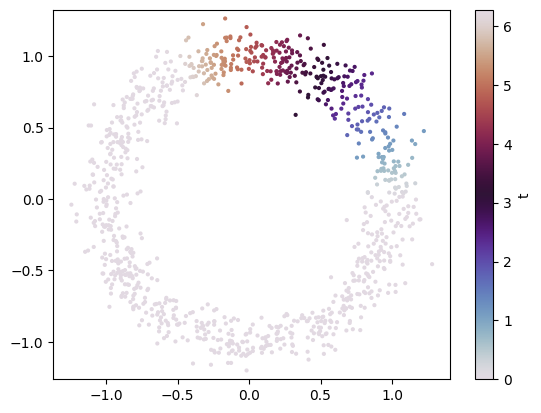

In [128]:
plt.scatter(x, y, c=t_MilB, cmap='twilight', s=4)   # s 是点大小，按需调
plt.axis('equal')
plt.colorbar(label='t')   # 可选，显示色条
plt.show()


# X=S^1, B Z_q-coordinates

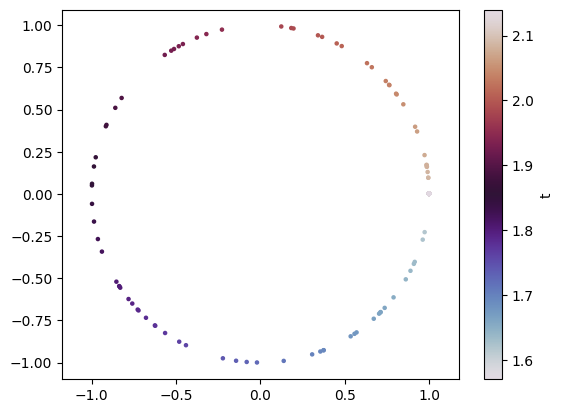

In [188]:
x_t=np.cos(t)
y_t=np.sin(t)
plt.scatter(x_t, y_t, c=theta, cmap='twilight', vmin=1.57, vmax=2.14, s=5)   # s 是点大小，按需调
plt.axis('equal')
plt.colorbar(label='t')   # 可选，显示色条
plt.show()

In [189]:
# Base values for each oriented 1-simplex (in standard order)
q = 5
group = eg_tools.make_Zq(q)

eta_base_values = {
    (0, 1): 1,
    (0, 2): 0,
    (1, 2): 0,
}

In [190]:
EiMacCoords, etas_by_dim = exn.compute_EiMac_coords(eta_base_values, open_cover_filtration, group, data_S1, centers, gamma1, 
                               geodesic_distance, dims_to_keep=(0, 1))

*** Running Eilenberg-MacLane Algorithm ***
Creating eta.
Validating eta:
✓ eta is a Čech 1-cochain over F_Z_5.
✓ eta is a Čech cocycle.
→ Setting up bump functions g's
· len(g) = 3  (g[0] is None placeholder)

Dimension Lowering:
✓ δ(lifted_eta[i]) == (eta | cover[i])
✓ (lifted_eta[i] | U_i ∩ U_j) - (lifted_eta[j] | U_i ∩ U_j) is a cocycle on U_i ∩ U_j
→ Computing j_sharp(Q(i_sharp(eta))) [from dim 1 to dim 0]
· iter i=1 starting...
· iter i=1 done in 0.3s
· iter i=2 starting...
· iter i=2 done in 0.4s
· Q^1(-) is Done
✓ δ(Q(i_sharp(eta)))  ==  i_sharp(eta)   as Čech cocycles over F_EG.
· New Cech cochain's section is updated as: None
· New eta is a Cech 0-cocycle
→ Gluing eta into a classifying map

Eilenberg-MacLane coordinates is done:
· Domain (index): 0 ~ 999
· Codomain: BG(Z_5)


In [191]:
# EiMacCoords（BG-valued）
stats_1 = exn.dimension_tuple_stats_on_sheaf_section(EiMacCoords, depth=1)
print(stats_1)
print(f"Non-trivial bars: {sum(stats_1.values())} / {len(EiMacCoords.domain)}")       # 非平凡 bar 总数

Counter({1: 83})
Non-trivial bars: 83 / 1000


In [192]:
# max degree = 1. Let's draw the 1-skeleton
coords_2d = rep.Repr_BarB_Z_q_1_to_wedge_q_minus_1_circles(q, EiMacCoords)
coords_2d.shape

(1000, 2)

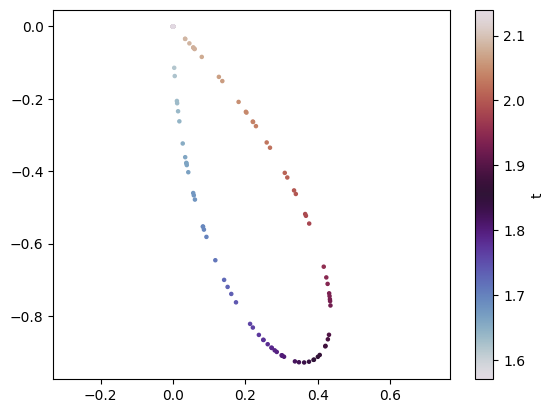

In [193]:
plt.scatter(coords_2d[:,0], coords_2d[:,1], c=theta, cmap='twilight', vmin=1.57, vmax=2.14, s=5)   # s 是点大小，按需调
plt.axis('equal')
plt.colorbar(label='t')   # 可选，显示色条
plt.show()

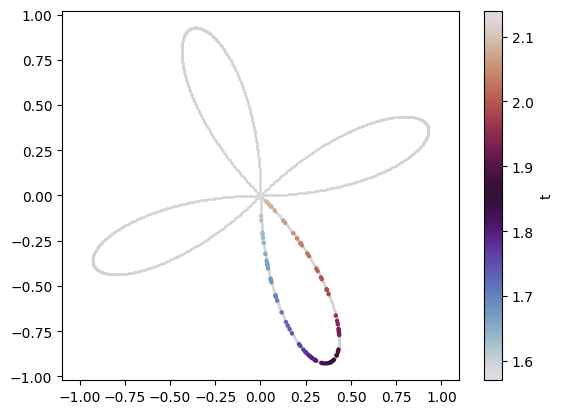

In [194]:
# 稠密枚举 BG(Z_q) 的所有非平凡 bar：g0=1,...,q-1，t0 在 [0,1] 稠密取点
K = 300   # 每个 lobe 上采多少个点，越大越平滑
synthetic_bars = [
    {'t': [t0, 1 - t0], 'g': [g0]}
    for g0 in range(1, q)
    for t0 in np.linspace(0, 1, K)
]

fake_domain = list(range(len(synthetic_bars)))
fake_section = sheaves.SheafSection(
    grp=eg_tools.make_BG(eg_tools.make_Zq(q)),
    func=lambda idx: synthetic_bars[idx],
    domain=fake_domain,
)

coords_bg = rep.Repr_BarB_Z_q_1_to_wedge_q_minus_1_circles(q, fake_section)

plt.scatter(coords_bg[:, 0], coords_bg[:, 1], c='lightgray', s=1, zorder=0)   # 值域背景
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], c=theta, cmap='twilight', vmin=1.57, vmax=2.14, s=5, zorder=1)   # 实际数据
plt.axis('equal')
plt.colorbar(label='t')
plt.show()

In [130]:
import plotly.graph_objects as go
# plot

# coordinates[:,3] = 1 - coordinates[:,0]
# coordinates[:,2] = coordinates[:,0] + coordinates[:,1]
# arg(z1)/2pi = 1 - t0
# arg(z0)/2pi = t0 + t1 = 1 - (t0 + t1)

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=coords_2d[:,0],
            y=coords_2d[:,1],
            z=coords_2d[:,2],
            mode='markers',
            marker=dict(
                size=3,
                color=theta,
                colorscale='Viridis',
                opacity=0.8,
                colorbar=dict(
                    title="data[:,0]"
                )
            )
        )
    ]
)

fig.update_layout(
    scene=dict(
        aspectmode='data'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

IndexError: index 2 is out of bounds for axis 1 with size 2

# Example: X=S^2, B B Z-coordinates

(4000, 3)


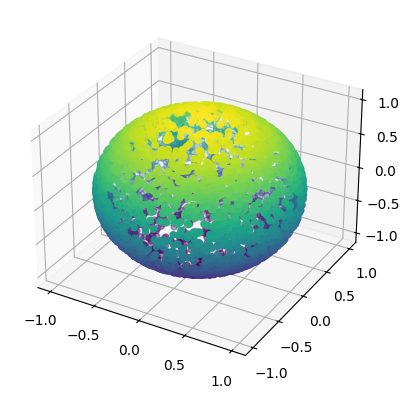

In [37]:
data = GeometryExamples.sphere(4000)
print(data.shape)

import matplotlib.pyplot as plt
fig = plt.figure()
ax = plt.axes(projection='3d')
_ = ax.scatter3D(data[:,0], data[:,1], data[:,2],s=20, c=data[:,2])

In [38]:
def geodesic_distance(x,y): # x and y both live in R^3
    return np.arccos(x[0]*y[0]+x[1]*y[1]+x[2]*y[2])

In [39]:
lower_bound = geodesic_distance([0, 0, -1], [2*np.sqrt(2)/3, 0, -1/3]) # 1.23
upper_bound = geodesic_distance([0, 0, 1], [2*np.sqrt(2)/3, 0, -1/3]) # 1.91
print(lower_bound, upper_bound)

1.2309594173407747 1.9106332362490184


In [40]:
gamma1 = [upper_bound, 1.8, 1.7, 1.6]

In [41]:
centers = [[0, 0, 1], [2*np.sqrt(2)/3, 0, -1/3], [-np.sqrt(2)/3, np.sqrt(6)/3, -1/3], [-np.sqrt(2)/3, -np.sqrt(6)/3, -1/3]]
exn.nerve(data, centers, geodesic_distance, radius=upper_bound)

Single sets:
U(0): 2513
U(1): 2592
U(2): 2678
U(3): 2704

2-fold intersections:
U(0,1): 1427
U(0,2): 1477
U(0,3): 1460
U(1,2): 1496
U(1,3): 1543
U(2,3): 1571

3-fold intersections:
U(0,1,2): 617
U(0,1,3): 621
U(0,2,3): 613
U(1,2,3): 636

4-fold intersections:
U(0,1,2,3): 0


In [42]:
open_cover_filtration = exn.compute_open_cover_filtration(data, centers, gamma1, geodesic_distance)

# Base values for each oriented 2-simplex (in standard order)
group = eg_tools.Z

eta_base_values = {
    (0, 1, 2): 1,
    (0, 1, 3): 0,
    (0, 2, 3): 0,
    (1, 2, 3): 0,
}

In [43]:
EiMacCoords, etas_by_dim = exn.compute_EiMac_coords(eta_base_values, open_cover_filtration, group, data, centers, gamma1, 
                               geodesic_distance, dims_to_keep=(0, 1))

*** Running Eilenberg-MacLane Algorithm ***
Creating eta.
Validating eta:
✓ eta is a Čech 2-cochain over F_Z.
✓ eta is a Čech cocycle.
→ Setting up bump functions g's
· len(g) = 4  (g[0] is None placeholder)

Dimension Lowering:
✓ δ(lifted_eta[i]) == (eta | cover[i])
✓ (lifted_eta[i] | U_i ∩ U_j) - (lifted_eta[j] | U_i ∩ U_j) is a cocycle on U_i ∩ U_j
→ Computing j_sharp(Q(i_sharp(eta))) [from dim 2 to dim 1]
· iter i=1 starting...
· iter i=1 done in 6.0s
· iter i=2 starting...
· iter i=2 done in 7.8s
· iter i=3 starting...
· iter i=3 done in 9.2s
· Q^2(-) is Done
✓ δ(Q(i_sharp(eta)))  ==  i_sharp(eta)   as Čech cocycles over F_EG.
· New Cech cochain's section is updated as: None
· New eta is a Cech 1-cocycle

Dimension Lowering:
✓ δ(lifted_eta[i]) == (eta | cover[i])
✓ (lifted_eta[i] | U_i ∩ U_j) - (lifted_eta[j] | U_i ∩ U_j) is a cocycle on U_i ∩ U_j
→ Computing j_sharp(Q(i_sharp(eta))) [from dim 1 to dim 0]
· iter i=1 starting...
· iter i=1 done in 5.7s
· iter i=2 starting...
· iter

In [44]:
# EiMacCoords（BBG-valued）
stats_2, by_sig = exn.dimension_tuple_stats_on_sheaf_section(EiMacCoords, depth=2, return_indices=True)
print(stats_2)
# print(by_sig[(1,1)])
print("")
for idx in by_sig[(1,1)]:
    print(f"idx={idx}: {EiMacCoords(idx)}")
print("")
# print(stats_2.most_common(10))     # 例如 [((1,1), 27), ((2,1), 5), ...]

print(f"Non-trivial bars: {sum(stats_2.values())} / {len(EiMacCoords.domain)}")       # 非平凡 bar 总数

Counter({(1, 1): 2})

idx=927: {'t': [0.8436033169994476, 0.11513351415609796, 0.04126316884445447], 'g': [{'t': [0.9587368311555455, 0.04126316884445447], 'g': [1]}, {'t': [0.8436033169994476, 0.15639668300055243], 'g': [-1]}]}
idx=3433: {'t': [0.7371646100950462, 0.13024697279313857, 0.13258841711181524], 'g': [{'t': [0.8674115828881848, 0.13258841711181524], 'g': [1]}, {'t': [0.7371646100950462, 0.2628353899049538], 'g': [-1]}]}

Non-trivial bars: 2 / 4000


# Example: X=S^2 (with local density), B B Z-coordinates

In [45]:
def condition(i,x,gamma): # i=1,2,3; returns boolean - true: if in the critical zones
    X = [[0, 0, 1], [2*np.sqrt(2)/3, 0, -1/3], [-np.sqrt(2)/3, np.sqrt(6)/3, -1/3], [-np.sqrt(2)/3, -np.sqrt(6)/3, -1/3]]
    if i==0:
        return geodesic_distance(x,[-0.272,0.922,-0.272])<0.17
#    boolean1 = (geodesic_distance(x,X[i])<gamma[3])
#    boolean2 = False
#    for k in range(i):
#        boolean2 = boolean2 or (geodesic_distance(x, X[k])<gamma[k])
#    boolean3 = True
#    for k in range(i):
#        boolean3 = boolean3 and (geodesic_distance(x, X[k])>gamma[k+1])
#    return (boolean1 and boolean2 and boolean3)

def sample_condition_on_sphere_test(gamma, i=0, batch=400):
    pts_list = []
    count = 0
    while count < batch:
        pts = sphere_uniform(batch, rng=None)
        # print('count:', count,' batch:',batch)
        # 批量判断 condition
        mask = np.array([condition(i, p, gamma) for p in pts])
        good = pts[mask]

        pts_list.append(good)
        count += len(good)
    
    data = np.vstack(pts_list)
    return [data,mask]

def sphere_uniform(n, rng=None):
    rng = np.random.default_rng(rng)
    z = rng.uniform(-1.0, 1.0, size=n)
    phi = rng.uniform(0.0, 2*np.pi, size=n)
    r = np.sqrt(1 - z**2)
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    return np.column_stack([x, y, z])

In [46]:
[data_local,mask_local] = sample_condition_on_sphere_test(gamma1, i=0, batch=800)

data = GeometryExamples.sphere(4000)
data_conditional = np.vstack([data, data_local]) # data_conditional = np.vstack([data, data1, data2, data3])
print(data_conditional.shape)

(4802, 3)


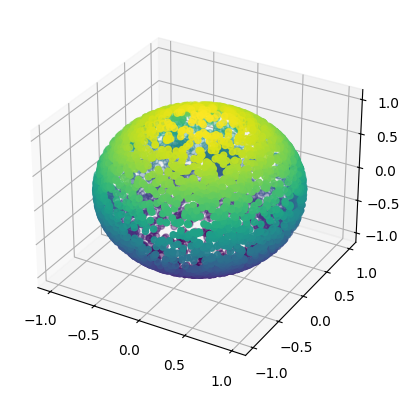

In [47]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = plt.axes(projection='3d')
_ = ax.scatter3D(data_conditional[:,0], data_conditional[:,1], data_conditional[:,2],s=20, c=data_conditional[:,2])

In [48]:
open_cover_filtration = exn.compute_open_cover_filtration(data_conditional, centers, gamma1, geodesic_distance)

# Base values for each oriented 2-simplex (in standard order)
group = eg_tools.Z
open_cover = open_cover_filtration[0]

eta_base_values = {
    (0, 1, 2): 1,
    (0, 1, 3): 0,
    (0, 2, 3): 0,
    (1, 2, 3): 0,
}

In [49]:
EiMacCoords, etas_by_dim = exn.compute_EiMac_coords(eta_base_values, open_cover_filtration, group, data_conditional, centers, gamma1, 
                               geodesic_distance, dims_to_keep=(0, 1))

*** Running Eilenberg-MacLane Algorithm ***
Creating eta.
Validating eta:
✓ eta is a Čech 2-cochain over F_Z.
✓ eta is a Čech cocycle.
→ Setting up bump functions g's
· len(g) = 4  (g[0] is None placeholder)

Dimension Lowering:
✓ δ(lifted_eta[i]) == (eta | cover[i])
✓ (lifted_eta[i] | U_i ∩ U_j) - (lifted_eta[j] | U_i ∩ U_j) is a cocycle on U_i ∩ U_j
→ Computing j_sharp(Q(i_sharp(eta))) [from dim 2 to dim 1]
· iter i=1 starting...
· iter i=1 done in 7.7s
· iter i=2 starting...
· iter i=2 done in 10.8s
· iter i=3 starting...
· iter i=3 done in 9.1s
· Q^2(-) is Done
✓ δ(Q(i_sharp(eta)))  ==  i_sharp(eta)   as Čech cocycles over F_EG.
· New Cech cochain's section is updated as: None
· New eta is a Cech 1-cocycle

Dimension Lowering:
✓ δ(lifted_eta[i]) == (eta | cover[i])
✓ (lifted_eta[i] | U_i ∩ U_j) - (lifted_eta[j] | U_i ∩ U_j) is a cocycle on U_i ∩ U_j
→ Computing j_sharp(Q(i_sharp(eta))) [from dim 1 to dim 0]
· iter i=1 starting...
· iter i=1 done in 8.6s
· iter i=2 starting...
· ite

In [50]:
# EiMacCoords（BBG-valued）
stats_2, by_sig = exn.dimension_tuple_stats_on_sheaf_section(EiMacCoords, depth=2, return_indices=True)
print(stats_2)
# print(by_sig[(1,1)])
print("")
for idx in by_sig[(1,1)][0:5]:
    print(f"idx={idx}: {EiMacCoords(idx)}")
print("")
# print(stats_2.most_common(10))     # 例如 [((1,1), 27), ((2,1), 5), ...]

print(f"Non-trivial bars: {sum(stats_2.values())} / {len(EiMacCoords.domain)}")       # 非平凡 bar 总数

Counter({(1, 1): 118})

idx=927: {'t': [0.8436033169994476, 0.11513351415609796, 0.04126316884445447], 'g': [{'t': [0.9587368311555455, 0.04126316884445447], 'g': [1]}, {'t': [0.8436033169994476, 0.15639668300055243], 'g': [-1]}]}
idx=3433: {'t': [0.7371646100950462, 0.13024697279313857, 0.13258841711181524], 'g': [{'t': [0.8674115828881848, 0.13258841711181524], 'g': [1]}, {'t': [0.7371646100950462, 0.2628353899049538], 'g': [-1]}]}
idx=4002: {'t': [0.10758842348348885, 0.6335703484526218, 0.2588412280638893], 'g': [{'t': [0.7411587719361107, 0.2588412280638893], 'g': [1]}, {'t': [0.10758842348348885, 0.8924115765165112], 'g': [-1]}]}
idx=4012: {'t': [0.6595209344311097, 0.007100365140210174, 0.3333787004286801], 'g': [{'t': [0.6666212995713199, 0.3333787004286801], 'g': [1]}, {'t': [0.6595209344311097, 0.3404790655688903], 'g': [-1]}]}
idx=4022: {'t': [0.2299137759401646, 0.33535333796432454, 0.43473288609551086], 'g': [{'t': [0.5652671139044891, 0.43473288609551086], 'g': [1]}, {'t'

In [51]:
# Realize all bars {t: [t0, t1, t2], g: [z0, z1]} in terms of coordinates [t0, t1, ~z0, ~z1]
# where ~z0 = arg(z0)/2pi, ~z1 = arg(z1)/2pi

coordinates = []
for i in range(len(EiMacCoords.domain)):
    if len(EiMacCoords(i)['t'])==1: # length == 0
        coordinates.append([0,0,0,0])
    else: # others fall into the type {t: [t0, t1, t2], g: [z0, z1]}
        coordinates.append([EiMacCoords(i)['t'][0],EiMacCoords(i)['t'][1],mtm.arg_0_2pi(rep.BZ_to_S1(EiMacCoords(i)['g'][0]))/(2*math.pi),mtm.arg_0_2pi(rep.BZ_to_S1(EiMacCoords(i)['g'][1]))/(2*math.pi)])
coordinates = np.array(coordinates)

In [52]:
# Dimensionality Reduction

# Highly suspect that:
# t0 + t1 - ~z0 = 0
# t0 + ~z1 = 1

# Hence we only need t0 and t1 to sketch on everything

print(max(abs(coordinates[:,0]+coordinates[:,1]-coordinates[:,2])))
idxs = np.all(coordinates[:,[0,1,3]] == 0, axis=1)
coordinates_test = np.delete(coordinates, 2, axis=1)
coordinates_test[idxs] = [0,0,1] # [0,0,0] ~ [0,0,1] are identified in quotient
print(max(abs(coordinates_test[:,0]+coordinates_test[:,2]-1)))

2.220446049250313e-16
1.1102230246251565e-16


In [53]:
import plotly.graph_objects as go
# plot

# coordinates[:,3] = 1 - coordinates[:,0]
# coordinates[:,2] = coordinates[:,0] + coordinates[:,1]
# arg(z1)/2pi = 1 - t0
# arg(z0)/2pi = t0 + t1 = 1 - (t0 + t1)

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=coordinates[:,0],
            y=coordinates[:,1],
            z=coordinates[:,2],
            mode='markers',
            marker=dict(
                size=3,
                color=coordinates[:,3],
                colorscale='Viridis',
                opacity=0.8,
                colorbar=dict(
                    title="data[:,0]"
                )
            )
        )
    ]
)

fig.update_layout(
    scene=dict(
        aspectmode='data'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

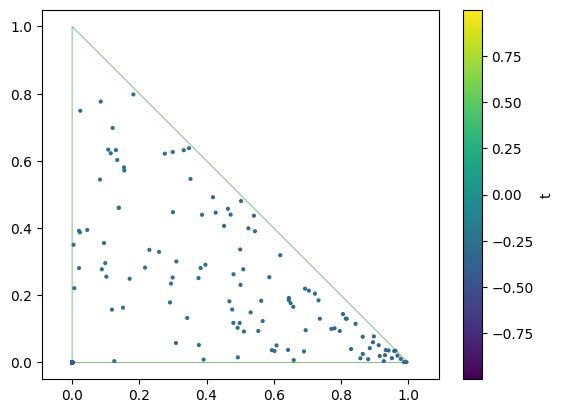

In [54]:
plt.scatter(coordinates[:,0], coordinates[:,1], c=data_conditional[:,0], cmap='viridis', s=4)   # s 是点大小，按需调
plt.axis('equal')
plt.colorbar(label='t')   # 可选，显示色条

# Reference Triangle (0,0)–(1,0)–(0,1)
tri_x = [0, 1, 0, 0]    # Back to (0,0) to close
tri_y = [0, 0, 1, 0]
plt.plot(tri_x, tri_y, color='green', linewidth=0.7, alpha=0.5, zorder=0) # zorder: to put the reference line at the bottom

plt.show()

In [55]:
import numpy as np

# 取前两列（x, y），逐行算
sphere_coords = np.array([
    mtm.Riemann_sphere_to_Sphere(
        mtm.standard_2simplex_to_Riemann_sphere(row)
    )
    for row in coordinates[:, :2]
])

print(sphere_coords.shape)   # (N, 3)

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=sphere_coords[:,0],
            y=sphere_coords[:,1],
            z=sphere_coords[:,2],
            mode='markers',
            marker=dict(
                size=3,
                color=data_conditional[:,0],
                colorscale='Viridis',
                cmin=-0.36,
                cmax=-0.24,
                opacity=0.8,
                colorbar=dict(
                    title="data[:,0]"
                )
            )
        )
    ]
)

fig.update_layout(
    scene=dict(
        aspectmode='data'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

(4802, 3)


In [56]:
mask_idx = (coordinates[:,0] > 0) & (coordinates[:,1] > 0)

import plotly.graph_objects as go

fig = go.Figure(data=[
    # Trace 1: 非 mask 点，按 z 上色
    go.Scatter3d(
        x=data_conditional[~mask_idx, 0],
        y=data_conditional[~mask_idx, 1],
        z=data_conditional[~mask_idx, 2],
        mode='markers',
        marker=dict(
            size=3,
            color=data_conditional[~mask_idx, 2],
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title="data[:,2]"),
        ),
        name='others',
    ),
    # Trace 2: mask 点，红色高亮
    go.Scatter3d(
        x=data_conditional[mask_idx, 0],
        y=data_conditional[mask_idx, 1],
        z=data_conditional[mask_idx, 2],
        mode='markers',
        marker=dict(size=4, color='red', opacity=0.9),
        name='mask (x>0 & y>0)',
    ),
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    margin=dict(l=0, r=0, b=0, t=0),
)

fig.show()

# X=S^2, MilB B Z-coordinates

In [57]:
eta_1_S1 = rep.cech_cochain_BZ_to_S1(etas_by_dim[1])

In [58]:
cc.validate_cech_cocycle(eta_1_S1)

True

In [59]:
milg_list = exn.dim1_cech_cocycle_to_MilB_G(eta_1_S1, centers, gamma1[0], data, geodesic_distance)
print("#Missing Elements: ", sum(1 for x in milg_list if not isinstance(x, dict)))  # NaN 数量

#Missing Elements:  0


In [60]:
milg_list[32:35]

[{'t': [0.46943816435520735, 0.14691260248416763, 0.0, 0.38364923316062494],
  'g': [(1+0j), (1+0j), (1+0j), (1+0j)]},
 {'t': [0.0, 0.0, 0.665416416848163, 0.334583583151837],
  'g': [(1+0j), (1+0j), (1+0j), (1+0j)]},
 {'t': [0.0, 0.47501192451180346, 0.5249880754881965, 0.0],
  'g': [(1+0j), (1+0j), (1+0j), (1+0j)]}]

In [61]:
rep.MilEG_S1_to_CPinf(milg_list[32])

array([0.68515558+0.j, 0.3832918 +0.j, 0.        +0.j, 0.61939425+0.j])

In [62]:
# Apply MilEG_S1_to_CPinf to every entry of milg_list, propagating NaN for
# data points not covered by any U_k.
CPinf_list = [
    rep.MilEG_S1_to_CPinf(milg) if isinstance(milg, dict) else milg
    for milg in milg_list
]

print(f"CPinf_list has {len(CPinf_list)} entries")
print(f"Non-NaN count: {sum(1 for v in CPinf_list if not isinstance(v, float))}")
print(f"Sample: CPinf_list[35] =", CPinf_list[35])

# Dimension reduction statistics on milg_list.
# For each MilEG bar, count the number of "active" centers — i.e. positions
# i with t_i > tol. Bars whose active set is small live on a low-dimensional
# face of the join product and could in principle be represented in lower
# ambient dimension.
from collections import Counter

tol = 1e-9

n_active_counter      = Counter()   # how many active centers
active_subset_counter = Counter()   # which centers are active

for milg in milg_list:
    if not isinstance(milg, dict):
        continue   # skip NaN
    active = tuple(i for i, t_i in enumerate(milg['t']) if t_i > tol)
    n_active_counter[len(active)] += 1
    active_subset_counter[active]  += 1

print()
print(f"Total non-NaN MilEG bars: {sum(n_active_counter.values())}")
print(f"Distribution of # active centers (t_i > {tol}):")
for k in sorted(n_active_counter):
    print(f"  {k} active center(s): {n_active_counter[k]} bars")

print()
print("Most common active-center subsets:")
for subset, n in active_subset_counter.most_common(10):
    print(f"  centers {subset}: {n} bars")


CPinf_list has 4000 entries
Non-NaN count: 4000
Sample: CPinf_list[35] = [0.66126551+0.j 0.5837194 +0.j 0.47116832+0.j 0.        +0.j]

Total non-NaN MilEG bars: 4000
Distribution of # active centers (t_i > 1e-09):
  2 active center(s): 1513 bars
  3 active center(s): 2487 bars

Most common active-center subsets:
  centers (1, 2, 3): 636 bars
  centers (0, 1, 3): 621 bars
  centers (0, 1, 2): 617 bars
  centers (0, 2, 3): 613 bars
  centers (2, 3): 322 bars
  centers (1, 3): 286 bars
  centers (0, 2): 247 bars
  centers (1, 2): 243 bars
  centers (0, 3): 226 bars
  centers (0, 1): 189 bars


In [63]:
X = np.array(CPinf_list)
print(X.shape)

# X.shape = (4000, 4), complex
X = np.asarray(X, dtype=np.complex128)

# normalize representatives
X = X / np.linalg.norm(X, axis=1, keepdims=True)

# Fubini–Study distance matrix on CP^3
G = X @ X.conj().T
A = np.abs(G)
A = np.clip(A, 0.0, 1.0)
D = np.arccos(A)

(4000, 4)


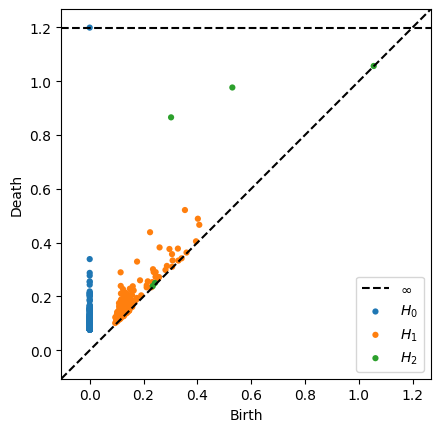

In [64]:
from ripser import ripser
from persim import plot_diagrams
diagrams = ripser(D, coeff=2, distance_matrix = True, maxdim=2, n_perm=500)['dgms']
plot_diagrams(diagrams, show=True)

In [65]:
from sklearn.manifold import Isomap

# Isomap
iso = Isomap(
    n_neighbors=10,
    n_components=8,
    metric='precomputed'
)
Y = iso.fit_transform(D)
print(Y.shape)

(4000, 8)


In [66]:
err = iso.reconstruction_error()
print(err)

0.13920729044874383


In [67]:
eigenvalues = np.cumsum(iso.kernel_pca_.eigenvalues_)
print(eigenvalues)
explained = eigenvalues/eigenvalues[-1]
print(explained)

[1556.96799847 2920.62153697 4063.85301252 4218.48717844 4341.50779057
 4416.18362838 4488.3094805  4550.09310571]
[0.34218377 0.64188171 0.89313623 0.92712107 0.95415801 0.97056995
 0.98642146 1.        ]


In [68]:
import plotly.graph_objects as go

# plot
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=Y[:,0],
            y=Y[:,1],
            z=Y[:,2],
            mode='markers',
            marker=dict(
                size=3,
                color=data[:,0],
                colorscale='Viridis',
                opacity=0.8,
                colorbar=dict(
                    title="data[:,0]"
                )
            )
        )
    ]
)

fig.update_layout(
    scene=dict(
        aspectmode='data'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [69]:
from sklearn.metrics import pairwise_distances

D_new = pairwise_distances(Y, metric='euclidean')
print(D_new.shape)

(4000, 4000)


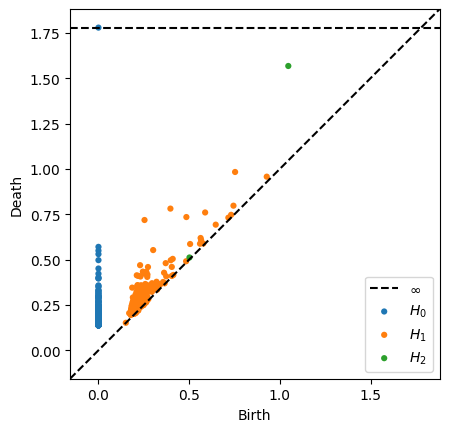

In [70]:
from ripser import ripser
from persim import plot_diagrams
diagrams = ripser(D_new, coeff=2, distance_matrix = True, maxdim=2, n_perm=500)['dgms']
plot_diagrams(diagrams, show=True)

In [71]:
reduced_coords_tony = mtm.ppca(np.array(CPinf_list),1)
print(reduced_coords_tony['variance'])
print(reduced_coords_tony['X'][0:9])

[0.2148399  0.16945064 0.14966561]
[[ 0.99488918+1.12733995e-03j -0.09617783+3.07257427e-02j]
 [ 0.92850703+8.90175253e-05j  0.37131206-1.43028246e-03j]
 [ 0.90180651+1.20916854e-03j -0.43083184+3.35778986e-02j]
 [ 0.76477474+1.61171365e-03j -0.64359383+3.00662557e-02j]
 [ 0.98018821+1.71749443e-03j -0.19605825+2.80942019e-02j]
 [ 0.99944908+4.60346816e-04j -0.01198853-3.09452460e-02j]
 [ 0.98711441+6.76503159e-04j  0.15747367+2.84029031e-02j]
 [ 0.79298134-1.68370154e-04j  0.60898223+1.79222643e-02j]
 [ 0.74718945+1.71123892e-03j -0.66453206-1.01059020e-02j]]


In [72]:
coords_R3_tony = mtm.hopf_map(reduced_coords_tony['X'])
print(coords_R3_tony[0:3])

[[-0.19130329 -0.06135427  0.97961151]
 [ 0.68953146  0.00272216  0.72425061]
 [-0.77697271 -0.06160343  0.6265129 ]]


In [73]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=coords_R3_tony[:, 0],
            y=coords_R3_tony[:, 1],
            z=coords_R3_tony[:, 2],
            mode='markers',
            marker=dict(
                size=4,
                color=data[:, 0],
                colorscale='Viridis',
                opacity=0.8,
                colorbar=dict(
                    title="data[:, 0]"
                )
            )
        )
    ]
)

fig.update_layout(
    scene=dict(
        camera=dict(
            eye=dict(x=0, y=0, z=2)
        ),
        aspectmode='data'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()


# X=T^2, MilB B Z-coordinates

# X=M(Z_q,1), MilB B Z_q-coordinates

In [74]:
import numpy as np

# 6-vertex minimum triangulation of RP² = M(Z_2, 1).
# 10 faces, 15 edges, 6 vertices  →  χ = 6 - 15 + 10 = 1 = χ(RP²).
# Each edge appears in exactly 2 faces (closed 2-manifold condition).
faces_RP2 = [
    (0, 1, 3), (0, 1, 5), (0, 2, 3), (0, 2, 4), (0, 4, 5),
    (1, 2, 4), (1, 2, 5), (1, 3, 4), (2, 3, 5), (3, 4, 5),
]

N_samples = 4000
rng = np.random.default_rng(seed=0)   # 固定 seed for reproducibility

dataset_RP2 = []
for _ in range(N_samples):
    face = faces_RP2[rng.integers(0, len(faces_RP2))]
    t = rng.dirichlet([1, 1, 1])      # uniform on the 2-simplex (Lebesgue)
    dataset_RP2.append({'t': t.tolist(), 'v': list(face)})

print(f"Generated {len(dataset_RP2)} samples on RP² (uniform per face, then averaged over faces)")
print(f"Triangulation: 6 vertices, {len(faces_RP2)} faces")
print()
print("First 3 samples:")
for s in dataset_RP2[:3]:
    print(s)

Generated 4000 samples on RP² (uniform per face, then averaged over faces)
Triangulation: 6 vertices, 10 faces

First 3 samples:
{'t': [0.978807180998904, 0.019014278822406774, 0.0021785401786893178], 'v': [2, 3, 5]}
{'t': [0.19284115740092955, 0.5711341339024646, 0.23602470869660575], 'v': [1, 2, 5]}
{'t': [0.2316251582259134, 0.4981308577130289, 0.2702439840610577], 'v': [3, 4, 5]}


In [75]:
# 看分布
from collections import Counter
face_counter = Counter(tuple(s['v']) for s in dataset_RP2)
print("samples per face:", face_counter.most_common())
# 期望每个 face 大约 400 个样本

# 拿 t 矩阵和 v 矩阵分开（便于后续 NumPy 操作）
ts = np.array([s['t'] for s in dataset_RP2])         # shape (4000, 3)
vs = np.array([s['v'] for s in dataset_RP2])         # shape (4000, 3)

samples per face: [((1, 2, 5), 425), ((1, 3, 4), 414), ((0, 1, 3), 404), ((2, 3, 5), 401), ((1, 2, 4), 397), ((3, 4, 5), 396), ((0, 1, 5), 396), ((0, 2, 3), 391), ((0, 2, 4), 388), ((0, 4, 5), 388)]


In [76]:
def simplicial_l1_distance(pt1, pt2):
    """
    L^1 distance between two simplicial points (extended weight vectors).

    Each point is a dict {'t': [t_0, t_1, t_2], 'v': [v_0, v_1, v_2]}.
    Extend each to a weight assignment {vertex_idx -> weight}; vertices not
    appearing in v are taken to have weight 0. The distance is

        Σ_{v ∈ verts(pt1) ∪ verts(pt2)}  |w_1(v) - w_2(v)|

    This is a valid metric on the simplicial complex (positive, symmetric,
    triangle inequality). It is NOT the same as the strict PL Riemannian
    geodesic, but it is topologically equivalent and suffices for distance-
    based methods like Isomap, UMAP, k-NN graphs, etc.
    """
    w1 = dict(zip(pt1['v'], pt1['t']))
    w2 = dict(zip(pt2['v'], pt2['t']))
    all_verts = set(w1) | set(w2)
    return sum(abs(w1.get(v, 0.0) - w2.get(v, 0.0)) for v in all_verts)

In [77]:
# 同 face 上两点
p1 = {'t': [1.0, 0.0, 0.0], 'v': [0, 1, 3]}   # 在顶点 0
p2 = {'t': [0.0, 1.0, 0.0], 'v': [0, 1, 3]}   # 在顶点 1
upper_bound = simplicial_l1_distance(p1, p2)  # 期望 2.0

# 不同 face 共享边的两点（两点其实在共享边上同一位置）
p3 = {'t': [1/3, 1/3, 1/3], 'v': [0, 1, 3]}   # 在三角形 (0,1,3) 中点
p4 = {'t': [1.0, 0.0, 0.0], 'v': [0, 1, 3]}   # 在顶点 0
lower_bound = simplicial_l1_distance(p3, p4)   # 期望 0.0（同一点）

print(lower_bound, upper_bound)

# Let's set upper bound a bit less than 2.0 to avoid numerical issue
upper_bound = 1.999999999999
print(upper_bound)

1.3333333333333333 2.0
1.999999999999


In [78]:
gamma1 = [upper_bound, 1.9, 1.8, 1.7, 1.6, 1.5]

In [79]:
p0 = {'t': [1.0, 0.0, 0.0], 'v': [0, 1, 3]}   # Vertex 0
p1 = {'t': [0.0, 1.0, 0.0], 'v': [0, 1, 3]}   # Vertex 1
p2 = {'t': [0.0, 1.0, 0.0], 'v': [0, 2, 4]}   # Vertex 2
p3 = {'t': [0.0, 0.0, 1.0], 'v': [0, 1, 3]}   # Vertex 3
p4 = {'t': [0.0, 0.0, 1.0], 'v': [0, 2, 4]}   # Vertex 4
p5 = {'t': [0.0, 0.0, 1.0], 'v': [0, 2, 5]}   # Vertex 5

centers = [p0,p1,p2,p3,p4,p5]
exn.nerve(dataset_RP2, centers, simplicial_l1_distance, radius=1.5)

Single sets:
U(0): 1073
U(1): 1123
U(2): 1158
U(3): 1108
U(4): 1106
U(5): 1150

2-fold intersections:
U(0,1): 214
U(0,2): 193
U(0,3): 205
U(0,4): 181
U(0,5): 170
U(1,2): 206
U(1,3): 204
U(1,4): 163
U(1,5): 214
U(2,3): 184
U(2,4): 204
U(2,5): 239
U(3,4): 213
U(3,5): 196
U(4,5): 204

3-fold intersections:
U(0,1,2): 0
U(0,1,3): 27
U(0,1,4): 0
U(0,1,5): 33
U(0,2,3): 32
U(0,2,4): 23
U(0,2,5): 0
U(0,3,4): 0
U(0,3,5): 0
U(0,4,5): 23
U(1,2,3): 0
U(1,2,4): 23
U(1,2,5): 32
U(1,3,4): 20
U(1,3,5): 0
U(1,4,5): 0
U(2,3,4): 0
U(2,3,5): 25
U(2,4,5): 0
U(3,4,5): 34

4-fold intersections:
U(0,1,2,3): 0
U(0,1,2,4): 0
U(0,1,2,5): 0
U(0,1,3,4): 0
U(0,1,3,5): 0
U(0,1,4,5): 0
U(0,2,3,4): 0
U(0,2,3,5): 0
U(0,2,4,5): 0
U(0,3,4,5): 0
U(1,2,3,4): 0
U(1,2,3,5): 0
U(1,2,4,5): 0
U(1,3,4,5): 0
U(2,3,4,5): 0

5-fold intersections:
U(0,1,2,3,4): 0
U(0,1,2,3,5): 0
U(0,1,2,4,5): 0
U(0,1,3,4,5): 0
U(0,2,3,4,5): 0
U(1,2,3,4,5): 0

6-fold intersections:
U(0,1,2,3,4,5): 0


In [80]:
open_cover_filtration = exn.compute_open_cover_filtration(dataset_RP2, centers, gamma1, simplicial_l1_distance)

# Base values for each oriented 2-simplex (in standard order)
group = eg_tools.make_Zq(2)
open_cover = open_cover_filtration[0]

eta_base_values = {
    (0, 1, 3): 1,
    (0, 1, 5): 0,
    (0, 2, 3): 0,
    (0, 2, 4): 0,
    (0, 4, 5): 0,
    (1, 2, 4): 0,
    (1, 2, 5): 0,
    (1, 3, 4): 0,
    (2, 3, 5): 0,
    (3, 4, 5): 0
}

In [81]:
EiMacCoords, etas_by_dim = exn.compute_EiMac_coords(eta_base_values, open_cover_filtration, group, dataset_RP2, centers, gamma1, 
                               simplicial_l1_distance, dims_to_keep=(0, 1))

*** Running Eilenberg-MacLane Algorithm ***
Creating eta.
Validating eta:
✓ eta is a Čech 2-cochain over F_Z_2.
✓ eta is a Čech cocycle.
→ Setting up bump functions g's
· len(g) = 6  (g[0] is None placeholder)

Dimension Lowering:
✓ δ(lifted_eta[i]) == (eta | cover[i])
✓ (lifted_eta[i] | U_i ∩ U_j) - (lifted_eta[j] | U_i ∩ U_j) is a cocycle on U_i ∩ U_j
→ Computing j_sharp(Q(i_sharp(eta))) [from dim 2 to dim 1]
· iter i=1 starting...
· iter i=1 done in 4.4s
· iter i=2 starting...
· iter i=2 done in 7.3s
· iter i=3 starting...
· iter i=3 done in 8.1s
· iter i=4 starting...
· iter i=4 done in 9.9s
· iter i=5 starting...
· iter i=5 done in 11.5s
· Q^2(-) is Done
✓ δ(Q(i_sharp(eta)))  ==  i_sharp(eta)   as Čech cocycles over F_EG.
· New Cech cochain's section is updated as: None
· New eta is a Cech 1-cocycle

Dimension Lowering:
✓ δ(lifted_eta[i]) == (eta | cover[i])
✓ (lifted_eta[i] | U_i ∩ U_j) - (lifted_eta[j] | U_i ∩ U_j) is a cocycle on U_i ∩ U_j
→ Computing j_sharp(Q(i_sharp(eta))) [

In [82]:
# EiMacCoords（BBG-valued）
stats_2, by_sig = exn.dimension_tuple_stats_on_sheaf_section(EiMacCoords, depth=2, return_indices=True)
print(stats_2)
# print(stats_2.most_common(10))     # 例如 [((1,1), 27), ((2,1), 5), ...]

print(f"Non-trivial bars: {sum(stats_2.values())} / {len(EiMacCoords.domain)}")       # 非平凡 bar 总数

Counter()
Non-trivial bars: 0 / 4000


In [83]:
# EiMacCoords（BG-valued）
stats_1 = exn.dimension_tuple_stats_on_cech_cochain(etas_by_dim[1], depth=1)
print(stats_1)

{(0, 1): Counter({1: 13}), (0, 2): Counter(), (0, 3): Counter({1: 35}), (0, 4): Counter(), (0, 5): Counter(), (1, 2): Counter(), (1, 3): Counter({1: 48}), (1, 4): Counter(), (1, 5): Counter(), (2, 3): Counter(), (2, 4): Counter(), (2, 5): Counter(), (3, 4): Counter(), (3, 5): Counter(), (4, 5): Counter()}


In [84]:
cc.validate_cech_cocycle(etas_by_dim[1])

True

In [85]:
milg_list = exn.dim1_cech_cocycle_to_MilB_G(etas_by_dim[1], centers, gamma1[0], dataset_RP2, simplicial_l1_distance)
print("#Missing Elements: ", sum(1 for x in milg_list if not isinstance(x, dict)))  # NaN 数量

#Missing Elements:  0


In [86]:
milg_list[0]

{'t': [0.0,
  0.0,
  0.9788071809998723,
  0.019014278821935172,
  0.0,
  0.0021785401781925715],
 'g': [{'t': [1], 'g': []},
  {'t': [1], 'g': []},
  {'t': [1], 'g': []},
  {'t': [1.0], 'g': []},
  {'t': [1], 'g': []},
  {'t': [1.0], 'g': []}]}

In [87]:
from collections import Counter

# ----- 1. degree (= len(t)) check -----
TARGET_DEGREE = 6
bad_degree_indices = [i for i, b in enumerate(milg_list) if len(b['t']) != TARGET_DEGREE]

print(f"Total bars: {len(milg_list)}")
print(f"Target degree: {TARGET_DEGREE}")
print(f"Bars with degree != {TARGET_DEGREE}: {len(bad_degree_indices)}")
if bad_degree_indices:
    print("  offending indices and their degrees:")
    for i in bad_degree_indices[:50]:
        print(f"    i={i}: degree={len(milg_list[i]['t'])}")
    if len(bad_degree_indices) > 50:
        print(f"    ... ({len(bad_degree_indices) - 50} more)")
else:
    print("  -> all bars have the target degree.")

# ----- 2. effective vertex count (= number of nonzero t_i) per bar -----
def effective_vertex_count(bar, tol=0.0):
    return sum(1 for ti in bar['t'] if abs(ti) > tol)

eff_counts = [effective_vertex_count(b) for b in milg_list]

# distribution
count_dist = Counter(eff_counts)
print("\nDistribution of effective vertex count (#nonzero t_i):")
for k in sorted(count_dist):
    print(f"  {k} nonzero t : {count_dist[k]} bars")

print(f"\nMin effective vertex count : {min(eff_counts)}")
print(f"Max effective vertex count : {max(eff_counts)}")


Total bars: 4000
Target degree: 6
Bars with degree != 6: 0
  -> all bars have the target degree.

Distribution of effective vertex count (#nonzero t_i):
  3 nonzero t : 4000 bars

Min effective vertex count : 3
Max effective vertex count : 3


In [88]:
# ----- 3. max degree of g_i at nonzero-t positions -----
max_g_degree = 0
arg_max = None   # (bar index, position) where the max is attained

for bar_idx, bar in enumerate(milg_list):
    for i, ti in enumerate(bar['t']):
        if abs(ti) > 0.0:                              # nonzero t position
            gi = bar['g'][i]
            deg = len(gi['t'])                         # degree of the nested bar
            if deg > max_g_degree:
                max_g_degree = deg
                arg_max = (bar_idx, i)

print(f"\nMax degree of g_i over nonzero-t positions: {max_g_degree}")
if arg_max is not None:
    bi, pos = arg_max
    
    print(f"  attained at: milg_list[{bi}]['g'][{pos}] = {milg_list[bi]['g'][pos]}")


Max degree of g_i over nonzero-t positions: 2
  attained at: milg_list[41]['g'][3] = {'t': [0.44658593612987796, 0.553414063870122], 'g': [1]}


In [89]:
# ----- 4. distribution of nonzero-t position patterns -----
# For each bar, extract the sorted tuple of positions where t_i != 0,
# then count how many bars share each pattern.

nonzero_patterns = [
    tuple(i for i, ti in enumerate(b['t']) if abs(ti) > 0.0)
    for b in milg_list
]

pattern_dist = Counter(nonzero_patterns)

print(f"\nDistinct nonzero-position patterns: {len(pattern_dist)}")
print("Pattern  -> #bars")
for pat in sorted(pattern_dist):
    print(f"  {list(pat)}  ->  {pattern_dist[pat]}")


Distinct nonzero-position patterns: 10
Pattern  -> #bars
  [0, 1, 3]  ->  404
  [0, 1, 5]  ->  396
  [0, 2, 3]  ->  391
  [0, 2, 4]  ->  388
  [0, 4, 5]  ->  388
  [1, 2, 4]  ->  397
  [1, 2, 5]  ->  425
  [1, 3, 4]  ->  414
  [2, 3, 5]  ->  401
  [3, 4, 5]  ->  396


In [90]:
import numpy as np
import matplotlib.pyplot as plt


# ---- Vertex positions (polar -> Cartesian) ----
def _polar(r, theta):
    return np.array([r * np.cos(theta), r * np.sin(theta)])

_V_INNER = {
    3: _polar(0.5, 0.0),
    4: _polar(0.5, 2 * np.pi / 3),
    5: _polar(0.5, 4 * np.pi / 3),
}
_V_OUTER_CASE1 = {   # 1 of {3,4,5} in v  (so 2 of {0,1,2} in v)
    0: _polar(1.0, 0.0),
    1: _polar(1.0, 4 * np.pi / 3),
    2: _polar(1.0, 2 * np.pi / 3),
}
_V_OUTER_CASE2 = {   # 2 of {3,4,5} in v  (so 1 of {0,1,2} in v)
    0: _polar(1.0, np.pi),
    1: _polar(1.0, np.pi / 3),
    2: _polar(1.0, 5 * np.pi / 3),
}


def embed_dataset_RP2_to_R2(dataset):
    """
    Barycentric embedding of dataset_RP2 samples into R^2.

    Vertex positions:
      - v3, v4, v5 (inner triangle) fixed at radius 1/2.

      - v0, v1, v2 (outer hexagon): position depends on n_inner and, when
        n_inner == 1, on which specific inner vertex is present.

    Rules
    -----
      n_inner == 3:  use v3, v4, v5 at radius 1/2.
      n_inner == 2:  use Case-2 outer positions
                     v0=(1,π), v1=(1,π/3), v2=(1,5π/3).
      n_inner == 1:  per-outer-vertex case, driven by which inner vertex is in v:
                     v0 -> Case 1 (1,0)       if inner == v3, else Case 2 (1,π)
                     v1 -> Case 1 (1,4π/3)    if inner == v5, else Case 2 (1,π/3)
                     v2 -> Case 1 (1,2π/3)    if inner == v4, else Case 2 (1,5π/3)
      n_inner == 0:  ValueError (no such face in the RP² triangulation).
    """
    coords = []
    for idx, sample in enumerate(dataset):
        t, v = sample['t'], sample['v']
        inner_present = [i for i in v if i in (3, 4, 5)]
        n_inner = len(inner_present)

        if n_inner == 3:
            positions = [_V_INNER[i] for i in v]

        elif n_inner == 2:
            positions = [
                _V_INNER[i] if i in (3, 4, 5) else _V_OUTER_CASE2[i]
                for i in v
            ]

        elif n_inner == 1:
            single_inner = inner_present[0]     # 3, 4, or 5
            positions = []
            for i in v:
                if i in (3, 4, 5):
                    positions.append(_V_INNER[i])
                elif i == 0:
                    positions.append(_V_OUTER_CASE1[0] if single_inner == 3
                                     else _V_OUTER_CASE2[0])
                elif i == 1:
                    positions.append(_V_OUTER_CASE1[1] if single_inner == 5
                                     else _V_OUTER_CASE2[1])
                elif i == 2:
                    positions.append(_V_OUTER_CASE1[2] if single_inner == 4
                                     else _V_OUTER_CASE2[2])

        else:
            raise ValueError(
                f"Sample {idx}: v = {v} contains none of {{3,4,5}}. "
                f"Cannot determine outer vertex positions."
            )

        point = sum(ti * pi for ti, pi in zip(t, positions))
        coords.append(point.tolist())

    return coords

_VERTEX_COLORS = {
    0: np.array([1.0, 0.0, 0.0]),   # red
    1: np.array([0.0, 0.85, 0.0]),   # green
    2: np.array([0.0, 0.7, 0.7]),   # cyan
    3: np.array([0.0, 0.0, 1.0]),   # blue
    4: np.array([1.0, 0.0, 1.0]),   # magenta
    5: np.array([0.7, 0.7, 0.0]),   # yellow
}

def plot_RP2_reference_lines(ax=None, show_labels=True):
    """Draw the RP² triangulation reference lines with the color scheme."""
    if ax is None:
        ax = plt.gca()

    inner_pos = [_V_INNER[3], _V_INNER[4], _V_INNER[5]]

    # (a) Inner triangle v3-v4-v5: solid black
    for i in range(3):
        p, q = inner_pos[i], inner_pos[(i + 1) % 3]
        ax.plot([p[0], q[0]], [p[1], q[1]], 'k-')

    # (b) 9 outer-inner solid black lines: each inner vertex connects only
    #     to the 3 nearest outer positions (the 120° arc around it).
    _NEAREST_OUTER_TO_INNER = {
        3: [_V_OUTER_CASE1[0],   # (1, 0)
            _V_OUTER_CASE2[1],   # (1, π/3)
            _V_OUTER_CASE2[2]],  # (1, 5π/3)
        4: [_V_OUTER_CASE2[1],   # (1, π/3)
            _V_OUTER_CASE1[2],   # (1, 2π/3)
            _V_OUTER_CASE2[0]],  # (1, π)
        5: [_V_OUTER_CASE2[0],   # (1, π)
            _V_OUTER_CASE1[1],   # (1, 4π/3)
            _V_OUTER_CASE2[2]],  # (1, 5π/3)
    }
    for inner_v, outer_list in _NEAREST_OUTER_TO_INNER.items():
        ip = _V_INNER[inner_v]
        for op in outer_list:
            ax.plot([op[0], ip[0]], [op[1], ip[1]], 'k-')

    # (c) Outer hexagon boundary (colored dashed)
    outer_pts = [(lbl, _V_OUTER_CASE1[lbl]) for lbl in (0, 1, 2)] + \
                [(lbl, _V_OUTER_CASE2[lbl]) for lbl in (0, 1, 2)]
    outer_sorted = sorted(
        outer_pts,
        key=lambda x: np.arctan2(x[1][1], x[1][0]) % (2 * np.pi)
    )
    color_map = {frozenset([0, 1]): 'red',
                 frozenset([0, 2]): 'green',
                 frozenset([1, 2]): 'blue'}
    for i in range(6):
        lbl_a, p_a = outer_sorted[i]
        lbl_b, p_b = outer_sorted[(i + 1) % 6]
        color = color_map[frozenset([lbl_a, lbl_b])]
        ax.plot([p_a[0], p_b[0]], [p_a[1], p_b[1]],
                linestyle='-', color=color, linewidth=1.5, alpha=0.9)

    # Labels
    if show_labels:
        for i, pos in _V_INNER.items():
            ax.text(pos[0], pos[1], f'v{i}',
                    ha='center', va='center', fontsize=10, color=_VERTEX_COLORS[i],
                    bbox=dict(facecolor='white', edgecolor='none', pad=1))
        for lbl, pos in outer_pts:
            ax.text(pos[0] * 1.1, pos[1] * 1.1, f'v{lbl}',
                    ha='center', va='center', fontsize=10, color=_VERTEX_COLORS[lbl])

    ax.set_aspect('equal')
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)

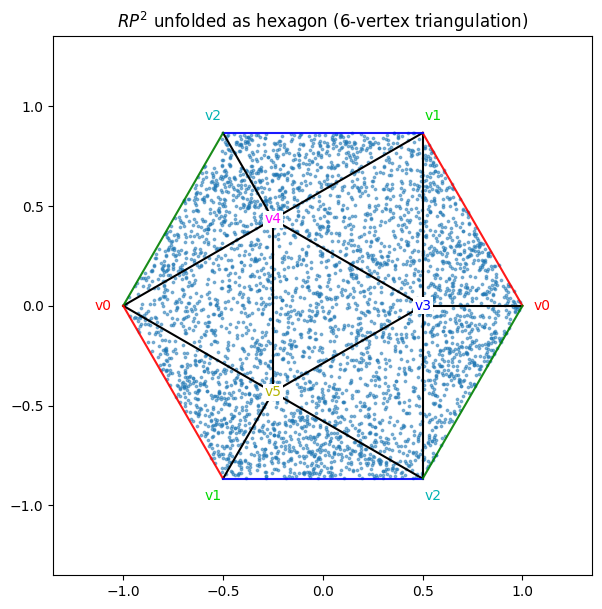

In [91]:
coords = np.array(embed_dataset_RP2_to_R2(dataset_RP2))

fig, ax = plt.subplots(figsize=(7, 7))
plot_RP2_reference_lines(ax)
ax.scatter(coords[:, 0], coords[:, 1], s=3, alpha=0.5, color='C0')
plt.title(r'$RP^2$ unfolded as hexagon (6-vertex triangulation)')
plt.show()

In [92]:
import numpy as np

def _inner_bar_to_arg(inner_bar):
    """
    identity bar {'t':[1],'g':[]}                  -> 0.0
    degree-1 bar {'t':[t0,t1], 'g':[g0]}           -> (2π * t0 * g0) mod 2π
    """
    if len(inner_bar['t']) == 1 and len(inner_bar['g']) == 0:
        return 0.0
    t0 = inner_bar['t'][0]
    g0 = inner_bar['g'][0]
    return (2.0 * np.pi * t0 * g0) % (2.0 * np.pi)


def compactify_milg_list(milg_list, tol=0.0):
    """
    For each MilEG bar in milg_list, keep only the nonzero-t positions and
    convert each surviving inner bar to a real angle in [0, 2π):
        - identity bar               -> 0
        - degree-1 bar (t0,t1; g0)   -> (2π * t0 * g0) mod 2π

    Returns
    -------
    list of dict, each of the form:
        {'t': [nonzero t values],
         'v': [positions of nonzero t values],
         'g': [inner-bar angles, one per position in v]}
    """
    compact = []
    for bar in milg_list:
        t_list = bar['t']
        g_list = bar['g']
        v      = [i for i, ti in enumerate(t_list) if abs(ti) > tol]
        compact.append({
            't': [t_list[i] for i in v],
            'v': v,
            'g': [_inner_bar_to_arg(g_list[i]) for i in v],
        })
    return compact


# Usage
milg_compact = compactify_milg_list(milg_list)
print(milg_compact[0])

{'t': [0.9788071809998723, 0.019014278821935172, 0.0021785401781925715], 'v': [2, 3, 5], 'g': [0.0, 0.0, 0.0]}


In [93]:
def rgb_add(colors, weights):
    """
    Weighted additive color mixing in RGB (each channel in [0, 1]).

    Returns   clip( sum_i w_i * c_i , 0, 1 )   component-wise.

    Parameters
    ----------
    colors : array-like of shape (N, 3)
        N input RGB colors, each a 3-tuple/array of floats in [0, 1].
    weights : array-like of shape (N,)
        N nonnegative weights.

    Returns
    -------
    numpy.ndarray of shape (3,), float in [0, 1]
        The clipped weighted sum.
    """
    colors  = np.asarray(colors,  dtype=float)   # (N, 3)
    weights = np.asarray(weights, dtype=float)   # (N,)
    return np.clip(weights @ colors, 0.0, 1.0)   # (3,)

In [94]:
import numpy as np

def color_loop(t, base_color):
    """
    Map t ∈ [0, 1] to an RGB color on a closed loop:

        gray  →  dark_c  →  c  →  light_c  →  gray

    where
        gray    = (0.5, 0.5, 0.5)
        dark_c  = 0.5 * c
        pure_c  = c
        light_c = 0.5 + 0.5 * c

    Piecewise-linear over 4 equal segments:
        [0.00, 0.25]:  gray  → dark
        [0.25, 0.50]:  dark  → pure
        [0.50, 0.75]:  pure  → light
        [0.75, 1.00]:  light → gray

    Parameters
    ----------
    t : float or array-like, values wrapped to [0, 1) via mod 1.
    base_color : 3-tuple of floats in [0, 1]  (default red).

    Returns
    -------
    numpy.ndarray of shape t.shape + (3,)   (or shape (3,) if t is scalar).
    All RGB values are guaranteed to lie in [0, 1].
    """
    c     = np.asarray(base_color, dtype=float)
    gray  = np.array([0.5, 0.5, 0.5])
    dark  = 0.5 * c
    pure  = c
    light = 0.5 + 0.5 * c

    is_scalar = np.isscalar(t)
    t_arr = np.atleast_1d(np.asarray(t, dtype=float)) % 1.0
    out = np.zeros(t_arr.shape + (3,))

    m1 = t_arr < 0.25
    m2 = (t_arr >= 0.25) & (t_arr < 0.5)
    m3 = (t_arr >= 0.5) & (t_arr < 0.75)
    m4 = t_arr >= 0.75

    s1 = (t_arr[m1] / 0.25)[:, None];               out[m1] = gray  * (1 - s1) + dark  * s1
    s2 = ((t_arr[m2] - 0.25) / 0.25)[:, None];      out[m2] = dark  * (1 - s2) + pure  * s2
    s3 = ((t_arr[m3] - 0.50) / 0.25)[:, None];      out[m3] = pure  * (1 - s3) + light * s3
    s4 = ((t_arr[m4] - 0.75) / 0.25)[:, None];      out[m4] = light * (1 - s4) + gray  * s4

    return out[0] if is_scalar else out

In [95]:
def compute_colors_from_milg_compact(milg_compact):
    """
    Per-sample RGB color from compact MilEG bars.

    For a sample {'t': [t0, t1, t2], 'v': [v0, v1, v2], 'g': [g0, g1, g2]}:
      1. base_j     = _VERTEX_COLORS[v_j]
      2. shifted_j  = color_loop(g_j / (2*pi), base_color=base_j)
      3. return      rgb_add(colors=[shifted_0, shifted_1, shifted_2],
                              weights=[t_0,     t_1,     t_2])

    Returns
    -------
    np.ndarray of shape (N, 3), float in [0, 1]
    """
    N = len(milg_compact)
    out = np.zeros((N, 3), dtype=float)

    for i, sample in enumerate(milg_compact):
        t, v, g = sample['t'], sample['v'], sample['g']

        per_vertex = np.stack([
            color_loop(g[j] / (2.0 * np.pi),
                       base_color=_VERTEX_COLORS[v[j]])
            for j in range(3)
        ])   # shape (3, 3)

        out[i] = rgb_add(per_vertex, t)

    return out

Each position has a point actually living in S^1 * S^1 * S^1 with some quotient


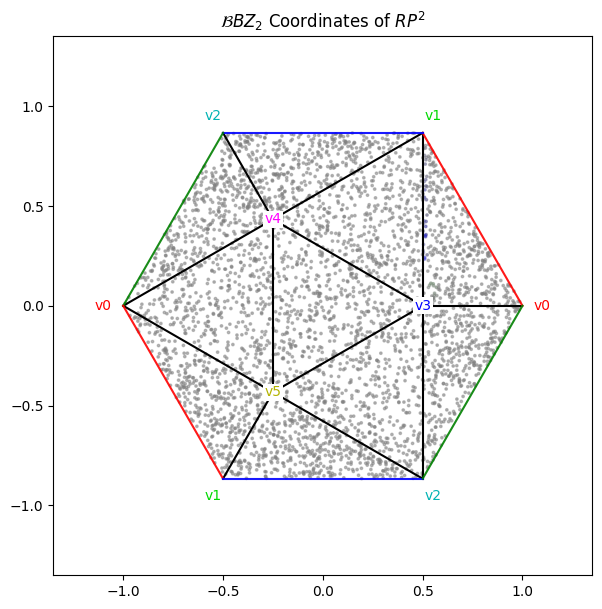

In [96]:
EM_coords = np.array(embed_dataset_RP2_to_R2(milg_compact))

print('Each position has a point actually living in S^1 * S^1 * S^1 with some quotient')

colors = compute_colors_from_milg_compact(milg_compact)

fig, ax = plt.subplots(figsize=(7, 7))
plot_RP2_reference_lines(ax)
sc = ax.scatter(
    EM_coords[:, 0], EM_coords[:, 1],
    s=3, alpha=0.5,
    c=colors,
)
plt.title(r'$\mathcal{B}BZ_2$ Coordinates of $RP^2$')
plt.show()

In [97]:
def _inner_bar_to_S1(inner_bar):
    """
    identity bar {'t':[1],'g':[]}                  -> 1 + 0j
    degree-1 bar {'t':[t0,t1], 'g':[g0]}           -> exp(2π i t0 g0)
    """
    if len(inner_bar['t']) == 1 and len(inner_bar['g']) == 0:
        return 1 + 0j
    t0 = inner_bar['t'][0]
    g0 = inner_bar['g'][0]
    return np.exp(2j * np.pi * t0 * g0)


def milg_list_to_t_and_g_S1(milg_list):
    """
    Same as `milg_list_to_t_and_g` but stores each inner bar as a unit-modulus
    complex number (S^1 element) instead of an angle:
        - identity bar                          -> 1 + 0j
        - degree-1 bar {'t':[t0,t1], 'g':[g0]}  -> exp(2π i t0 g0)

    Returns
    -------
    list of dict, each of the form:
        {'t': [t_0, ..., t_{n-1}],
         'g': [z_0, ..., z_{n-1}]}   with z_k complex, |z_k| = 1.
    """
    return [
        {'t': list(bar['t']),
         'g': [_inner_bar_to_S1(gi) for gi in bar['g']]}
        for bar in milg_list
    ]


# Usage
milg_t_g_S1 = milg_list_to_t_and_g_S1(milg_list)
print(milg_t_g_S1[0])

{'t': [0.0, 0.0, 0.9788071809998723, 0.019014278821935172, 0.0, 0.0021785401781925715], 'g': [(1+0j), (1+0j), (1+0j), (1+0j), (1+0j), (1+0j)]}


In [98]:
D = rep.distance_matrix_MilBS1_bars(milg_t_g_S1, normalize=False)

In [99]:
from sklearn.manifold import Isomap

# Isomap
iso = Isomap(
    n_neighbors=10,
    n_components=8,
    metric='precomputed'
)
Y = iso.fit_transform(D)
print(Y.shape)

(4000, 8)


In [100]:
err = iso.reconstruction_error()
print(err)

0.23831744325406168


In [101]:
eigenvalues = np.cumsum(iso.kernel_pca_.eigenvalues_)
print(eigenvalues)
explained = eigenvalues/eigenvalues[-1]
print(explained)

[1640.33962997 3211.60433239 4695.27491345 6162.10802044 7532.25818482
 7691.83752137 7834.51960145 7973.04207573]
[0.20573573 0.4028079  0.58889378 0.77286787 0.94471572 0.96473058
 0.98262615 1.        ]


In [102]:
from sklearn.metrics import pairwise_distances
D_new = pairwise_distances(Y, metric='euclidean')   # (N, N)

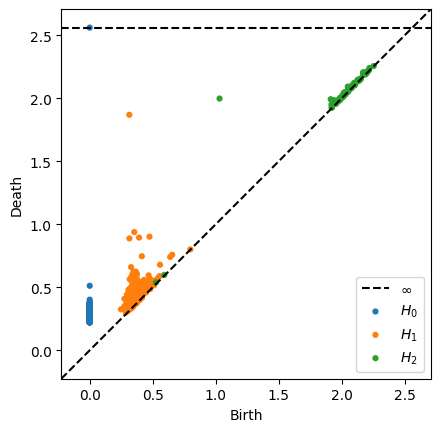

In [103]:
from ripser import ripser
from persim import plot_diagrams
diagrams = ripser(D_new, coeff=2, distance_matrix = True, maxdim=2, n_perm=500)['dgms']
plot_diagrams(diagrams, show=True)

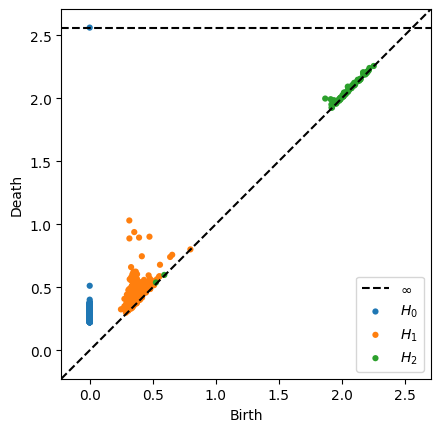

In [104]:
from ripser import ripser
from persim import plot_diagrams
diagrams = ripser(D_new, coeff=3, distance_matrix = True, maxdim=2, n_perm=500)['dgms']
plot_diagrams(diagrams, show=True)

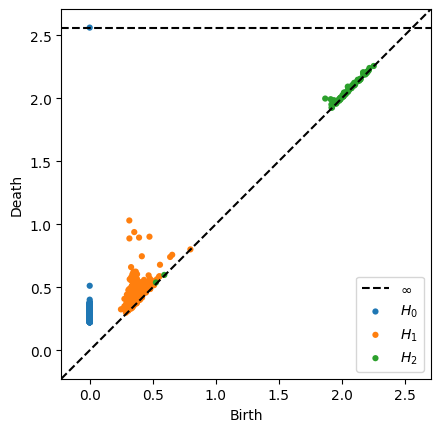

In [105]:
from ripser import ripser
from persim import plot_diagrams
diagrams = ripser(D_new, coeff=5, distance_matrix = True, maxdim=2, n_perm=500)['dgms']
plot_diagrams(diagrams, show=True)

In [106]:
import plotly.graph_objects as go

# plot
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=Y[:,0],
            y=Y[:,1],
            z=Y[:,2],
            mode='markers',
            marker=dict(
                size=3,
                color=Y[:,3],
                colorscale='Viridis',
                opacity=0.8,
                colorbar=dict(
                    title="Y[:,3]"
                )
            )
        )
    ]
)

fig.update_layout(
    scene=dict(
        aspectmode='data'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

#plot with hovering affects

#test with 64 enconding



fig = go.Figure(data=[

    go.Scatter3d(x=theta1, y=theta2, z=theta3,

        mode='markers', marker=dict(size = 2, color =energy, colorscale='plasma')

    )

])



# turn off native plotly.js hover effects - make sure to use

# hoverinfo="none" rather than "skip" which also halts events.

fig.update_traces(hoverinfo="none", hovertemplate=None)

fig.update_layout(

    scene = dict(

        xaxis = dict(range=[-1,8],),

        yaxis = dict(range=[-1,8],),

        zaxis = dict(range=[-1,8],),

    ), width=700, height=700

)



app = JupyterDash(__name__)



server = app.server



app.layout = html.Div([

    dcc.Graph(id="graph-basic-2", figure=fig, clear_on_unhover=True),

    dcc.Tooltip(id="graph-tooltip"),

])





@app.callback(

    Output("graph-tooltip", "show"),

    Output("graph-tooltip", "bbox"),

    Output("graph-tooltip", "children"),

    Input("graph-basic-2", "hoverData"),

)



def display_hover(hoverData):

    if hoverData is None:

        return False, no_update, no_update



    # demo only shows the first point, but other points may also be available

    pt = hoverData["points"][0]

    bbox = pt["bbox"]

    num = pt["pointNumber"]



    img_fname = 'images/'+str(num+1)+'.png'

    encoded_img = base64.b64encode(open(img_fname, 'rb').read())



    children = [

        html.Div([

            html.Img(src='data:image/png;base64,{}'.format(encoded_img.decode()), style={'width': '100%'}),

        ], style={'width': '80px', 'white-space': 'normal'})

    ]



    return True, bbox, children



app.run_server(mode="inline")